In [12]:
import numpy as np
import pandas as pd 
import geopandas as gpd 
import matplotlib.pyplot as plt 
from shapely.geometry import Polygon, MultiPolygon

In [9]:
def remove_holes(geom):
    if geom.geom_type == "Polygon":
        return Polygon(geom.exterior)  # mantém só o contorno externo
    elif geom.geom_type == "MultiPolygon":
        # acessa cada polígono dentro do MultiPolygon
        return MultiPolygon([Polygon(p.exterior) for p in geom.geoms])
    else:
        return geom

In [13]:
df_muni = gpd.read_file('../../imdc_2026/data/shape_muni.gpkg')

df_muni["geometry"] = df_muni.buffer(0)

df_uf = df_muni.dissolve(by="uf")

df_uf["geometry"] = df_uf["geometry"].apply(remove_holes)

df_uf["geometry"] = df_uf.buffer(1e-9).buffer(-1e-9)

# reset index if you want 'uf' back as a column
df_uf = df_uf.reset_index()

df_uf.head()

/tmp/ipykernel_76877/2140947459.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  df_uf["geometry"] = df_uf.buffer(1e-9).buffer(-1e-9)


,uf,geometry,geocode,geocode_name,uf_code
0,AC,"POLYGON ((-70.51515 -7.79238, -70.05498 -7.845...",1200013,Acrelândia,12
1,AL,"MULTIPOLYGON (((-38.23759 -9.3298, -38.23759 -...",2700102,Água Branca,27
2,AM,"POLYGON ((-72.37321 -4.83344, -72.37321 -4.833...",1300029,Alvarães,13
3,AP,"MULTIPOLYGON (((-54.87625 2.42669, -54.87625 2...",1600055,Serra do Navio,16
4,BA,"MULTIPOLYGON (((-46.57715 -11.36086, -46.57715...",2900108,Abaíra,29


Teixeira de Freitas (BA) - geocode: 2931350
Vitória da Conquista (BA) - geocode: 2933307
Brejo Santo (CE) - geocode: 2302503
Coronel Fabriciano (MG) - geocode: 3119401
São José do Rio Preto (SP) - geocode: 3549805
Presidente Prudente (SP) - geocode: 3541406
Rio Branco (AC) - geocode: 1200401
Cruzeiro do Sul (AC) - geocode: 1200203
Paraíso do Tocantins (TO) - geocode: 1716109
Londrina (PR) - geocode: 4113700
Cambé (PR) - geocode: 4103701
Cascavel (PR) - geocode: 4104808
Aparecida de Goiânia (GO) - geocode: 5201405
Campo Novo do Parecis (MT) - geocode: 5102637
Novo Gama (GO) - geocode: 5215231

In [39]:
geocode = 2931350
df_ = df_muni.loc[df_muni.geocode == geocode]
df_.head()

,geocode,geocode_name,uf,uf_code,geometry
2214,2931350,Teixeira de Freitas,BA,29,"POLYGON ((-39.72129 -17.28062, -39.71462 -17.2..."


In [44]:
x

array([-39.78684929])

In [50]:
geocodes = [ 2931350, 2933307, 2302503,
            3119401, 3549805,3541406, 1200401,
            1200203, 1716109, 4113700, 4103701,
            4104808,5201405,5102637,5215231]

/tmp/ipykernel_76877/129369581.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  x  = df_.geometry.centroid.x.values
/tmp/ipykernel_76877/129369581.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  y = df_.geometry.centroid.y.values


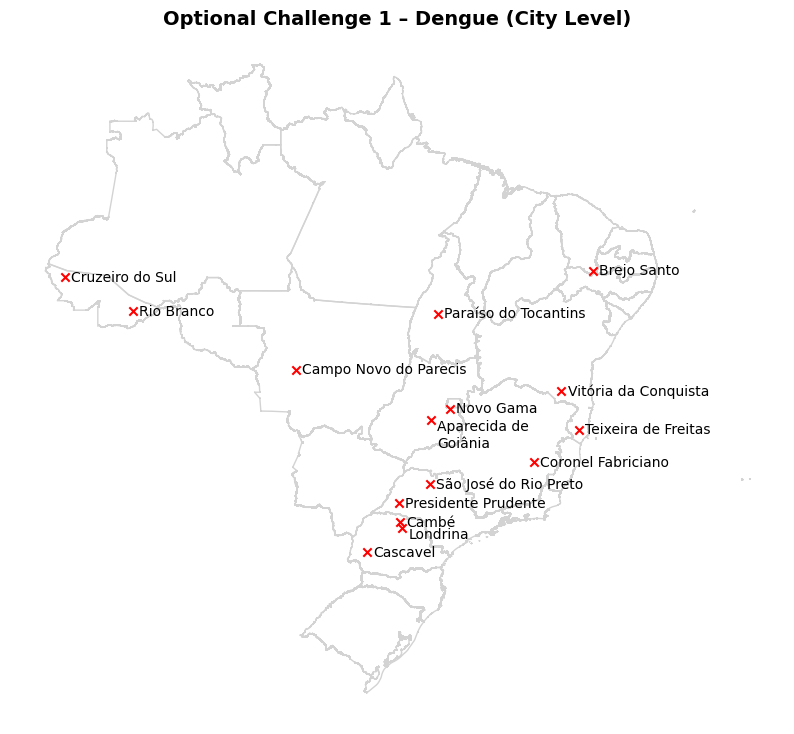

In [73]:
_, ax = plt.subplots(figsize = (10, 10))

df_uf.boundary.plot(ax=ax, linewidth = 1, color = 'lightgray')

for geo in geocodes: 

    df_ = df_muni.loc[df_muni.geocode == geo]
    x  = df_.geometry.centroid.x.values
    y = df_.geometry.centroid.y.values
    name = df_.geocode_name.values[0]

    ax.scatter(x,y, marker = 'x', color = 'red', zorder = 2)

    if name == 'Aparecida de Goiânia':

        name = 'Aparecida de\nGoiânia'

        ax.annotate(name, (x[0] + 0.4,y[0]),
                ha = 'left', va = 'top')

    elif name == 'Londrina':
        ax.annotate(name, (x[0] + 0.4,y[0]),
                ha = 'left', va = 'top')
        
    else: 

        ax.annotate(name, (x[0] + 0.4,y[0]),
                ha = 'left', va = 'center')

ax.axis('off')

ax.set_title('Optional Challenge 1 – Dengue (City Level)', fontsize = 14, 
                 fontweight="bold"
)
plt.savefig('add_dengue_city.png', dpi = 300, bbox_inches = 'tight')
plt.show()

In [74]:
geocodes_chik = [2211001,2931350, 3143302, 3119401,
                  1721000,1716109,4104808,4219507,
                  5103403,5102637]

/tmp/ipykernel_76877/1124872354.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  x  = df_.geometry.centroid.x.values
/tmp/ipykernel_76877/1124872354.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  y = df_.geometry.centroid.y.values


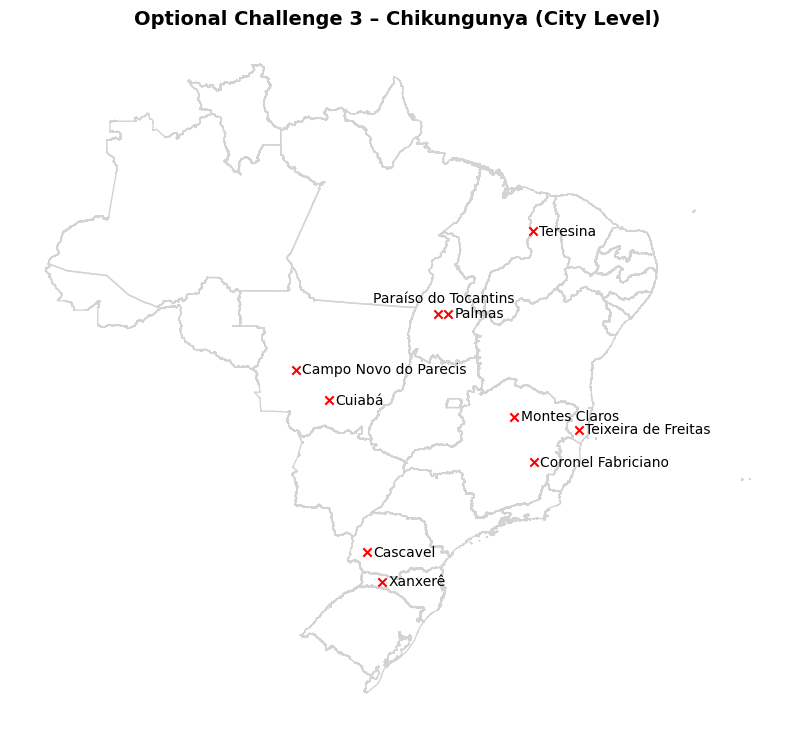

In [82]:
_, ax = plt.subplots(figsize = (10, 10))

df_uf.boundary.plot(ax=ax, linewidth = 1, color = 'lightgray')

for geo in geocodes_chik: 

    df_ = df_muni.loc[df_muni.geocode == geo]
    x  = df_.geometry.centroid.x.values
    y = df_.geometry.centroid.y.values
    name = df_.geocode_name.values[0]

    ax.scatter(x,y, marker = 'x', color = 'red', zorder = 2)

    if name == 'Aparecida de Goiânia':

        name = 'Aparecida de\nGoiânia'

        ax.annotate(name, (x[0] + 0.4,y[0]),
                ha = 'left', va = 'top')

    elif name == 'Paraíso do Tocantins':
        ax.annotate(name, (x[0] + 0.4,y[0]+0.5),
                ha = 'center', va = 'bottom')
        
    else: 

        ax.annotate(name, (x[0] + 0.4,y[0]),
                ha = 'left', va = 'center')

ax.axis('off')

ax.set_title('Optional Challenge 3 – Chikungunya (City Level)', fontsize = 14, 
                 fontweight="bold"
)
plt.savefig('add_chik_city.png', dpi = 300, bbox_inches = 'tight')
plt.show()